# Нейро-сотрудник: Тендерный консультант по 44-ФЗ

Данный ноутбук реализует полноценного RAG-агента для консультирования поставщиков по вопросам 44-ФЗ. В работе задействованы самые современные техники улучшения качества ответов: гибридный поиск, переранжирование, граф знаний, валидация ответов и трассировка.

**Стек:** Python, LlamaIndex, HuggingFace Transformers, Phoenix (OpenInference), Pyvis.

**Контурная модель:** saiga_mistral_7b (4‑bit NF4 + LoRA) - русскоязычная, оптимизирована для диалогов.

## 1. Установка и импорт библиотек

Устанавливаются все необходимые пакеты: трансформеры для загрузки модели, LlamaIndex для RAG-пайплайна, Phoenix для трассировки, а также вспомогательные библиотеки (pyvis для визуализации графов, rank_bm25 для BM25). Импортируются ключевые модули. На этом этапе также подавляются излишние предупреждения, чтобы не засорять вывод.

In [ ]:
!pip install -q "transformers>=4.41,<5" sentence-transformers \
    accelerate bitsandbytes peft sentencepiece
print('Базовые зависимости установлены')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
Базовые зависимости установлены


In [ ]:
!pip install -q llama-index langchain langchain-community \
    llama-index-llms-huggingface llama-index-embeddings-huggingface \
    llama-index-embeddings-langchain langchain-huggingface huggingface-hub \
    llama-index-postprocessor-flag-embedding-reranker FlagEmbedding
print('LlamaIndex установлен')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.7/247.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.8/947.8 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.5/164.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.6/142.6 kB 8

In [ ]:
!pip install -q -U "arize-phoenix>=19" sqlean.py gcsfs nest-asyncio \
    "openinference-instrumentation-llama-index>=2.0.0" \
    pypdf sentence-transformers pyvis \
    llama-index-readers-wikipedia wikipedia rank_bm25

import logging
logging.getLogger("pip").setLevel(logging.ERROR)

print('Дополнительные пакеты установлены')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.8/332.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 86.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 54.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.1/91.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.2/217.2 kB 20.4 MB/s eta 0:00:00
   ━━

In [ ]:
import os
import re
import json
import textwrap
import hashlib
from collections import OrderedDict
import warnings
warnings.filterwarnings('ignore')

import torch
from transformers import (
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig,
    GenerationConfig
)
from peft import PeftModel, PeftConfig

from llama_index.core import (
    VectorStoreIndex, SimpleDirectoryReader, Document,
    Settings, StorageContext, KnowledgeGraphIndex
)
from llama_index.core.graph_stores import SimpleGraphStore
from llama_index.llms.huggingface import HuggingFaceLLM
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core.node_parser import SentenceSplitter
from llama_index.core.retrievers import (
    VectorIndexRetriever, QueryFusionRetriever
)
from llama_index.core.postprocessor import LongContextReorder
from llama_index.core.query_engine import RetrieverQueryEngine, TransformQueryEngine
from llama_index.core.indices.query.query_transform import HyDEQueryTransform
from llama_index.core.llms import ChatMessage
from llama_index.core.ingestion import IngestionPipeline

from huggingface_hub import login
from google.colab import userdata

print('Библиотеки загружены')

Библиотеки загружены


In [ ]:
TOKEN = userdata.get("PARADISE_TAX_COLLECTOR_BOT_WITH_SHOTGUN_DEMANDING_CREDITS_FOR_SUNNY_BEACH_ACCESS_DENIED_13")
login(TOKEN, add_to_git_credential=True)
print("Вход в Hugging Face выполнен")

Вход в Hugging Face выполнен


## 2. Загрузка контурной модели saiga_mistral_7b

Выбрана модель **saiga_mistral_7b** - это русскоязычная версия Mistral 7B, дообученная на диалогах. Она хорошо справляется с задачами генерации ответов на русском языке. Для экономии памяти и ускорения используется **4‑битная квантизация (NF4)** с двойным квантованием и LoRA‑адаптером. Функции `messages_to_prompt` и `completion_to_prompt` адаптируют формат сообщений под ожидания Saiga. Это критично для корректного диалога.

In [ ]:
def messages_to_prompt(messages: list[ChatMessage]) -> str:
    """Преобразует список сообщений в строку-промпт для Saiga"""
    prompt = ''
    for message in messages:
        if message.role == 'system':
            prompt += f"<s>{message.role}\n{message.content}</s>\n"
        elif message.role == 'user':
            prompt += f"<s>{message.role}\n{message.content}</s>\n"
        elif message.role == 'assistant':
            prompt += f"<s>bot\n"
    if not prompt.startswith('<s>system\n'):
        prompt = '<s>system\n</s>\n' + prompt
    prompt = prompt + '<s>bot\n'
    return prompt


def completion_to_prompt(completion: str) -> str:
    """Преобразует строку завершения в промпт для Saiga"""
    return f"<s>system\n</s>\n<s>user\n{completion}</s>\n<s>bot\n"


print('Функции форматирования загружены')

Функции форматирования загружены


In [ ]:
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
)

MODEL_NAME = 'mistralai/Mistral-7B-v0.1'
LORA_NAME = 'IlyaGusev/saiga_mistral_7b'

print('Загружаем базовую модель + LoRA...')
config = PeftConfig.from_pretrained(LORA_NAME)
model = AutoModelForCausalLM.from_pretrained(
    config.base_model_name_or_path,
    quantization_config=quantization_config,
    torch_dtype=torch.float16, device_map='auto',
)
model = PeftModel.from_pretrained(model, LORA_NAME, torch_dtype=torch.float16)
model.eval()
tokenizer = AutoTokenizer.from_pretrained(LORA_NAME, use_fast=False)
generation_config = GenerationConfig.from_pretrained(LORA_NAME)
print('Модель загружена')

Загружаем базовую модель + LoRA...


adapter_config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/623 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin.index.json: 0.00B [00:00, ?B/s]

...

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/265 [00:00<?, ?B/s]

Модель загружена


In [ ]:
llm = HuggingFaceLLM(
    model=model, model_name=MODEL_NAME, tokenizer=tokenizer,
    max_new_tokens=generation_config.max_new_tokens,
    model_kwargs={'quantization_config': quantization_config},
    generate_kwargs={
        'bos_token_id': generation_config.bos_token_id,
        'eos_token_id': generation_config.eos_token_id,
        'pad_token_id': generation_config.pad_token_id,
        'no_repeat_ngram_size': generation_config.no_repeat_ngram_size,
        'repetition_penalty': generation_config.repetition_penalty,
        'temperature': 0.1,
        'do_sample': True, 'top_k': 50, 'top_p': 0.95,
    },
    messages_to_prompt=messages_to_prompt,
    completion_to_prompt=completion_to_prompt,
    device_map='auto',
)

embed_model = HuggingFaceEmbedding(
    model_name='sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
)

Settings.llm = llm
Settings.embed_model = embed_model
Settings.chunk_size = 512

print('LLM и эмбеддер готовы')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

LLM и эмбеддер готовы


## 3. Создание базы знаний 44-ФЗ

Создаётся набор документов - статей 44-ФЗ и одного постановления. Каждый документ содержит текст статьи и метаданные (источник, номер статьи, тема, домен). Это позволяет в дальнейшем фильтровать и аннотировать ответы. База охватывает ключевые аспекты: способы закупок, обеспечение, критерии оценки, требования к участникам, контроль и обжалование. Такой набор достаточен для демонстрации работы RAG-системы и выявления возможных галлюцинаций.

In [ ]:
data_44fz = [
    Document(text=textwrap.dedent("""
        Статья 24. Способы определения поставщиков (подрядчиков, исполнителей)
        1. Заказчики при осуществлении закупок используют следующие способы
        определения поставщиков (подрядчиков, исполнителей):
        1) конкурсы (открытый конкурс, конкурс с ограниченным участием,
        двухэтапный конкурс, закрытый конкурс, закрытый конкурс с ограниченным
        участием, закрытый двухэтапный конкурс);
        2) аукционы (аукцион в электронной форме, закрытый аукцион);
        3) запрос котировок;
        4) запрос предложений;
        5) закупка у единственного поставщика (подрядчика, исполнителя).
        """), metadata={'source': '44-ФЗ', 'article': '24',
            'topic': 'Способы определения поставщиков', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 42. Извещение о проведении электронного аукциона
        1. Извещение размещается заказчиком в ЕИС не менее чем за 15 дней
        до даты окончания срока подачи заявок.
        2. В извещении: наименование и описание объекта закупки, условия
        контракта, НМЦК, сроки поставки, размер обеспечения заявки и
        контракта, требования к участникам закупки.
        """), metadata={'source': '44-ФЗ', 'article': '42',
            'topic': 'Извещение и документация', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 44. Обеспечение заявок на участие в конкурсах и аукционах
        1. Обеспечение заявки на участие в электронном аукционе или конкурсе
        составляет от 0,5% до 5% начальной (максимальной) цены контракта.
        2. Если НМЦК не превышает одного млн рублей, обеспечение заявки
        не устанавливается.
        3. Обеспечение заявки может предоставляться в виде денежных средств
        или независимой гарантии. Денежные средства вносятся на спецсчёт
        в уполномоченном банке.
        """), metadata={'source': '44-ФЗ', 'article': '44',
            'topic': 'Обеспечение заявки', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 45. Независимая гарантия
        1. В качестве обеспечения заявок и исполнения контрактов могут
        предоставляться независимые гарантии, выдаваемые банками.
        2. Независимая гарантия должна быть безотзывной и содержать:
        сумму гарантии, срок действия, обязательства принципала.
        3. Срок действия независимой гарантии должен превышать срок
        исполнения контракта не менее чем на один месяц.
        """), metadata={'source': '44-ФЗ', 'article': '45',
            'topic': 'Независимая гарантия', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 93. Закупка у единственного поставщика
        1. Закупка у единственного поставщика может осуществляться в случаях:
        1) закупка товара, работы или услуги, которые относятся к сфере
        деятельности субъектов естественных монополий;
        2) закупка товаров, работ, услуг на сумму не более 600 тыс. рублей;
        4) закупка на сумму до 300 тыс. руб. (для образовательных,
        культурных учреждений до 600 тыс. руб.);
        6) закупка работы или услуги, которые могут осуществляться только
        органом исполнительной власти;
        9) закупка лекарственных препаратов при наличии решения врачебной
        комиссии.
        """), metadata={'source': '44-ФЗ', 'article': '93',
            'topic': 'Единственный поставщик', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 96. Обеспечение исполнения контракта
        1. Обеспечение исполнения контракта устанавливается в размере
        от 0,5% до 30% НМЦК, но не менее размера аванса.
        2. Если НМЦК до 50 млн рублей, размер обеспечения - от 5% до 30%.
        6. Обеспечение предоставляется до заключения контракта. Способ:
        денежные средства или независимая гарантия. Срок возврата -
        не более 30 дней с даты исполнения.
        """), metadata={'source': '44-ФЗ', 'article': '96',
            'topic': 'Обеспечение контракта', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 32. Оценка заявок участников закупки
        1. Для оценки заявок используются критерии:
        1) цена контракта (значимость не менее 30%);
        2) расходы на эксплуатацию и ремонт;
        3) качественные, функциональные и экологические характеристики;
        4) квалификация участников закупки.
        8. Совокупная значимость нестоимостных критериев - не менее 20%.
        """), metadata={'source': '44-ФЗ', 'article': '32',
            'topic': 'Критерии оценки', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 49. Порядок проведения электронного аукциона
        1. Электронный аукцион проводится на электронной площадке.
        2. Заявка состоит из двух частей: первая - согласие на поставку
        и информация о товаре, вторая - документы об участнике.
        5. Шаг аукциона: от 0,5% до 5% НМЦК.
        6. Время приёма предложений: 10 минут с последнего предложения.
        """), metadata={'source': '44-ФЗ', 'article': '49',
            'topic': 'Электронный аукцион', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 25.1. Требования к участникам закупки
        1. Участник закупки должен соответствовать требованиям:
        1) не проведение ликвидации участника;
        2) не наложение ареста на имущество;
        3) отсутствие недоимки по налогам свыше 25% балансовой стоимости;
        4) отсутствие судимости за экономические преступления;
        5) наличие исключительных прав на результаты интеллектуальной
        деятельности.
        """), metadata={'source': '44-ФЗ', 'article': '25.1',
            'topic': 'Требования к участникам', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Постановление Правительства РФ от 29.12.2021 N 2571
        О дополнительных требованиях к участникам
        Устанавливает дополнительные требования к участникам закупок
        отдельных видов товаров, работ, услуг.
        Для строительных работ: наличие лицензии МЧС, СРО.
        Для IT-услуг: наличие лицензии ФСТЭК на соответствующий вид
        деятельности.
        """), metadata={'source': 'ПП 2571', 'article': '-',
            'topic': 'Дополнительные требования к участникам', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 24.2. Особенности электронного аукциона
        1. Электронный аукцион проводится на электронной площадке, оператор
        которой обеспечивает проведение аукциона в соответствии с регламентом.
        2. Участник подает заявку в форме электронного документа.
        3. Рассмотрение первых частей заявок осуществляется аукционной комиссией
        в срок не более 1 рабочего дня с даты окончания срока подачи заявок.
        4. Аукцион проводится путем снижения НМЦК на шаг аукциона.
        5. Шаг аукциона составляет от 0,5% до 5% НМЦК.
        6. Время приема предложений от участников продлевается на 10 минут
        после поступления последнего предложения о цене контракта.
        """), metadata={'source': '44-ФЗ', 'article': '24.2',
            'topic': 'Электронный аукцион', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 26. Федеральный орган исполнительной власти по регулированию
        контрактной системы в сфере закупок
        1. Федеральный орган исполнительной власти по регулированию контрактной
        системы осуществляет функции по выработке государственной политики
        и нормативно-правовому регулированию в сфере закупок.
        2. К полномочиям органа относятся: установление порядка оценки заявок,
        определение типовых условий контрактов, мониторинг закупок,
        контроль в сфере закупок.
        """), metadata={'source': '44-ФЗ', 'article': '26',
            'topic': 'Регулирование закупок', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 30. Участие субъектов малого предпринимательства
        1. Заказчики обязаны осуществлять закупки у субъектов малого
        предпринимательства в объеме не менее 25% совокупного годового
        объема закупок.
        2. Начальная цена контракта при проведении закупки среди СМП
        не должна превышать 20 млн рублей.
        3. В случае неустановления преимуществ для СМП заказчик обязан
        предоставить отчет об объеме закупок у СМП.
        4. СМП могут привлекаться в качестве соисполнителей.
        """), metadata={'source': '44-ФЗ', 'article': '30',
            'topic': 'СМП', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 31. Требования к участникам закупки
        1. При осуществлении закупки заказчик устанавливает требования:
        1) соответствие требованиям законодательства РФ;
        2) правомочность участника заключать контракт;
        3) неприостановление деятельности в порядке КоАП;
        4) отсутствие недоимки по налогам и сборам;
        5) отсутствие судимости за преступления в сфере экономики;
        6) обладание исключительными правами на результаты интеллектуальной
        деятельности.
        2. Правительство РФ вправе устанавливать дополнительные требования.
        """), metadata={'source': '44-ФЗ', 'article': '31',
            'topic': 'Требования к участникам', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 34. Контракт
        1. Контракт заключается на условиях, предусмотренных извещением
        и заявкой участника.
        2. Контракт включает обязательное условие об ответственности сторон.
        3. Цена контракта является твердой и определяется на весь срок
        исполнения, за исключением случаев, предусмотренных законом.
        4. При заключении контракта запрещается изменять его условия,
        за исключением случаев снижения цены или увеличения объема.
        5. Расторжение контракта допускается по соглашению сторон,
        по решению суда или в одностороннем порядке.
        """), metadata={'source': '44-ФЗ', 'article': '34',
            'topic': 'Контракт', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 37. Антидемпинговые меры
        1. Если НМЦК более 15 млн рублей и участник снизил цену на 25%
        и более, он предоставляет обеспечение исполнения контракта
        в полуторном размере.
        2. Если НМЦК менее 15 млн рублей и участник снизил цену на 25%
        и более, он предоставляет обеспечение в полуторном размере
        или подтверждает добросовестность.
        3. Подтверждение добросовестности: информация об исполненных
        контрактах за последние 3 года (не менее 3 контрактов).
        """), metadata={'source': '44-ФЗ', 'article': '37',
            'topic': 'Антидемпинг', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 38. Комиссия по осуществлению закупок
        1. Заказчик создает комиссию по осуществлению закупок.
        2. Виды комиссий: конкурсная, аукционная, котировочная,
        единая комиссия.
        3. Число членов комиссии должно быть не менее 5 человек.
        4. Комиссия правомочна, если на заседании присутствует
        не менее 50% членов.
        5. Решение принимается большинством голосов.
        """), metadata={'source': '44-ФЗ', 'article': '38',
            'topic': 'Комиссия', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 46. Специализированная организация
        1. Заказчик вправе привлечь специализированную организацию
        для выполнения функций по определению поставщика.
        2. Специализированная организация осуществляет разработку
        документации, размещение извещения, организацию отбора.
        3. Заказчик несет ответственность за действия специализированной
        организации как за свои собственные.
        """), metadata={'source': '44-ФЗ', 'article': '46',
            'topic': 'Специализированная организация', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 50. Конкурсная документация
        1. Конкурсная документация разрабатывается и утверждается заказчиком.
        2. Документация содержит: наименование и описание объекта,
        НМЦК, требования к участникам, критерии оценки, условия контракта,
        размер и порядок внесения обеспечения.
        3. Срок подачи заявок на конкурс не менее 30 дней с даты размещения.
        4. Разъяснение документации осуществляется не позднее 2 дней
        до окончания срока подачи заявок.
        """), metadata={'source': '44-ФЗ', 'article': '50',
            'topic': 'Конкурсная документация', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 52. Вскрытие конвертов и открытие доступа к заявкам
        1. Вскрытие конвертов с заявками на участие в конкурсе
        осуществляется публично в день и время, указанные в документации.
        2. Информация объявляется и заносится в протокол: наименование
        и почтовый адрес участника, условия исполнения контракта.
        3. Протокол размещается в ЕИС в день вскрытия конвертов.
        """), metadata={'source': '44-ФЗ', 'article': '52',
            'topic': 'Вскрытие заявок', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 54. Рассмотрение и оценка заявок на участие в конкурсе
        1. Срок рассмотрения заявок не более 20 дней с даты вскрытия.
        2. Конкурсная комиссия отклоняет заявку, если участник не
        соответствует требованиям или заявка не соответствует документации.
        3. Оценка осуществляется по критериям, указанным в документации.
        4. Победитель - участник, предложивший лучшие условия.
        5. Протокол оценки размещается в ЕИС не позднее 1 дня.
        """), metadata={'source': '44-ФЗ', 'article': '54',
            'topic': 'Оценка заявок', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 66. Порядок подачи заявок на участие в электронном аукционе
        1. Заявка на участие в аукционе состоит из двух частей.
        2. Первая часть: согласие участника, конкретные показатели товара.
        3. Вторая часть: наименование, ИНН, документы об участнике.
        4. Заявка направляется оператору площадки в форме электронного
        документа.
        5. Участник вправе подать только одну заявку.
        """), metadata={'source': '44-ФЗ', 'article': '66',
            'topic': 'Подача заявок', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 67. Рассмотрение первых частей заявок
        1. Аукционная комиссия рассматривает первые части заявок
        в срок не более 1 рабочего дня с даты окончания их подачи.
        2. Основания для отклонения: недостоверная информация,
        несоответствие требованиям документации.
        3. Протокол рассмотрения размещается в ЕИС не позднее 1 дня.
        """), metadata={'source': '44-ФЗ', 'article': '67',
            'topic': 'Рассмотрение заявок', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 68. Порядок проведения электронного аукциона
        1. Аукцион проводится на электронной площадке в указанный день.
        2. Участники подают предложения о цене контракта.
        3. Время приема предложений: 10 минут с момента последнего.
        4. Снижение цены возможно на шаг аукциона (0,5-5% НМЦК).
        5. Победитель - участник, предложивший наименьшую цену.
        """), metadata={'source': '44-ФЗ', 'article': '68',
            'topic': 'Электронный аукцион', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 69. Рассмотрение вторых частей заявок
        1. Комиссия рассматривает вторые части заявок победителя аукциона.
        2. Срок рассмотрения не более 1 рабочего дня с даты размещения
        протокола аукциона.
        3. Основания для отклонения: непредоставление документов,
        несоответствие требованиям, недостоверность информации.
        4. Протокол подведения итогов размещается в ЕИС в день подписания.
        """), metadata={'source': '44-ФЗ', 'article': '69',
            'topic': 'Рассмотрение заявок', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 70. Заключение контракта по итогам аукциона
        1. Контракт заключается не ранее 10 дней и не позднее 20 дней
        с даты размещения протокола подведения итогов.
        2. Победитель подписывает контракт и предоставляет обеспечение.
        3. При уклонении победителя контракт заключается со вторым.
        4. Проект контракта размещается в ЕИС.
        """), metadata={'source': '44-ФЗ', 'article': '70',
            'topic': 'Заключение контракта', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 94. Приемка товаров, работ, услуг
        1. Приемка осуществляется в соответствии с условиями контракта.
        2. Для приемки может создаваться приемочная комиссия.
        3. Результаты приемки оформляются актом, который подписывается
        сторонами.
        4. При обнаружении недостатков составляется акт с перечнем
        и сроками устранения.
        5. Экспертиза результатов может проводиться силами заказчика
        или привлеченных экспертов.
        """), metadata={'source': '44-ФЗ', 'article': '94',
            'topic': 'Приемка', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 95. Изменение и расторжение контракта
        1. Изменение существенных условий контракта допускается
        в исключительных случаях: снижение цены, увеличение объема
        до 10%, изменение регулируемых цен.
        2. При сокращении финансирования стороны вправе уменьшить объем.
        3. Расторжение возможно по соглашению сторон, по решению суда,
        в одностороннем порядке.
        4. Заказчик обязан принять решение об одностороннем отказе
        при нарушении существенных условий контракта.
        """), metadata={'source': '44-ФЗ', 'article': '95',
            'topic': 'Изменение контракта', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 97. Мониторинг закупок
        1. Мониторинг закупок осуществляется Минфином России.
        2. Цель мониторинга: оценка эффективности закупок, выявление
        нарушений, совершенствование законодательства.
        3. Мониторинг проводится на основе данных ЕИС.
        4. Результаты мониторинга публикуются в ЕИС.
        """), metadata={'source': '44-ФЗ', 'article': '97',
            'topic': 'Мониторинг', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 99. Контроль в сфере закупок
        1. Контроль осуществляется ФАС России, органами внутреннего
        финансового контроля.
        2. Предмет контроля: соблюдение требований законодательства,
        обоснование НМЦК, применение антидемпинговых мер.
        3. Внеплановая проверка проводится при поступлении жалобы.
        4. Срок проведения проверки не более 30 дней.
        """), metadata={'source': '44-ФЗ', 'article': '99',
            'topic': 'Контроль', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 104. Реестр недобросовестных поставщиков
        1. Реестр ведется ФАС России в ЕИС.
        2. В реестр включается информация об участниках, уклонившихся
        от заключения контракта, и поставщиках, с которыми контракт
        расторгнут по решению суда.
        3. Срок включения в реестр - 2 года.
        4. Включение в реестр влечет ограничение на участие в закупках.
        """), metadata={'source': '44-ФЗ', 'article': '104',
            'topic': 'РНП', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 105. Обжалование действий заказчика
        1. Участник вправе обжаловать действия заказчика в ФАС.
        2. Жалоба подается в срок не более 10 дней с даты размещения
        протокола.
        3. Рассмотрение жалобы осуществляется в течение 5 рабочих дней.
        4. По результатам ФАС выдает предписание об устранении нарушений.
        5. Решение ФАС может быть обжаловано в суде.
        """), metadata={'source': '44-ФЗ', 'article': '105',
            'topic': 'Обжалование', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 107. Ответственность за нарушение законодательства
        1. Лица, виновные в нарушении законодательства о закупках,
        несут дисциплинарную, гражданско-правовую и административную
        ответственность.
        2. Административная ответственность установлена КоАП РФ.
        3. Должностные лица несут ответственность за нарушение сроков
        и порядка осуществления закупок.
        """), metadata={'source': '44-ФЗ', 'article': '107',
            'topic': 'Ответственность', 'domain': 'zakupki'}),
    Document(text=textwrap.dedent("""
        Статья 112. Переходные положения
        1. До 1 января 2025 года заказчики вправе не применять отдельные
        положения закона в отношении закупок до 500 тыс. рублей.
        2. Переходные положения применяются к контрактам, заключенным
        до вступления в силу изменений.
        3. До 2027 года действуют особенности для закупок в рамках
        импортозамещения.
        """), metadata={'source': '44-ФЗ', 'article': '112',
            'topic': 'Переходные положения', 'domain': 'zakupki'}),

]

print(f'Создано {len(data_44fz)} документов')

Создано 34 документов


## 4. Ingestion Pipeline + Чанкинг

Документы разбиваются на чанки размером 512 токенов с перекрытием 50 токенов. Это стандартный подход для баланса между полнотой контекста и скоростью обработки. Затем строится векторный индекс на основе эмбеддингов. Индекс сохраняется на диск, чтобы не перестраивать его при каждом запуске.

In [ ]:
pipeline = IngestionPipeline(
    transformations=[
        SentenceSplitter(chunk_size=512, chunk_overlap=50),
    ]
)

nodes = pipeline.run(documents=data_44fz, num_workers=2)
print(f'Создано {len(nodes)} чанков из документов')

index = VectorStoreIndex(nodes, embed_model=embed_model)
print('Векторный индекс создан')

index.storage_context.persist(persist_dir='./storage_44fz')
print('Индекс сохранён на диск')

Создано 34 чанков из документов
Векторный индекс создан
Индекс сохранён на диск


## 5. Системный промпт

Разработан системный промпт, который задаёт роль нейро-сотрудника - тендерный консультант. В промпте прописаны правила: отвечать только по контексту, ссылаться на статьи, добавлять блок «На практике важно», не предсказывать решения ФАС, уточнять двусмысленные вопросы. Такой промпт помогает снизить галлюцинации и делает ответы более профессиональными.

In [ ]:
SYSTEM_PROMPT = textwrap.dedent("""
Ты - Тендерный консультант для поставщиков. Опытный методист по 44-ФЗ.

Правила работы:
1. Отвечай ТОЛЬКО на основе предоставленного контекста (документов).
2. Если в контексте нет информации - скажи "Я не знаю. Эта информация
   отсутствует в моей базе знаний. Рекомендую обратиться к юристу."
3. Каждый ответ сопровождай ссылкой на статью 44-ФЗ (номер, часть, пункт).
4. Если вопрос не относится к госзакупкам - вежливо откажись.
5. После ответа добавляй блок "На практике важно:" с типичными ошибками
   поставщиков.
6. Не предсказывай решения ФАС или суда - только нормы закона.
7. При двусмысленном вопросе - уточни, что именно интересует.
8. В конце добавь дисклеймер.

Контекст:
{context_str}
""")

## 6. Ансамбль ретриверов (Dense + BM25) с RRF

Используется гибридный поиск: dense-ретривер на основе эмбеддингов (семантический) и BM25 (ключевые слова). Результаты объединяются через Reciprocal Rank Fusion (RRF), что даёт более устойчивые результаты, чем каждый из методов по отдельности. Это повышает recall и точность ретривала, особенно когда запрос содержит редкие термины.

In [ ]:
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.schema import NodeWithScore, QueryBundle
from rank_bm25 import BM25Okapi

retriever_dense = VectorIndexRetriever(
    index=index, similarity_top_k=10
)

corpus = [n.text for n in nodes]
tokenized_corpus = [doc.lower().split() for doc in corpus]
bm25 = BM25Okapi(tokenized_corpus)

class BM25Retriever:
    def retrieve(self, query: str | QueryBundle) -> list[NodeWithScore]:
        """Возвращает top-10 чанков по BM25 рангу"""
        query_str = query.query_str if isinstance(query, QueryBundle) else query
        tokenized_query = query_str.lower().split()
        scores = bm25.get_scores(tokenized_query)
        top_indices = sorted(
            range(len(scores)), key=lambda i: scores[i], reverse=True
        )[:10]
        return [
            NodeWithScore(node=nodes[i], score=scores[i])
            for i in top_indices
        ]

bm25_retriever = BM25Retriever()

fusion_retriever = QueryFusionRetriever(
    retrievers=[retriever_dense, bm25_retriever],
    similarity_top_k=5,
    num_queries=1,
    mode='reciprocal_rerank',
    use_async=False,
)

print('Ансамбль ретриверов создан')

Ансамбль ретриверов создан


## 7. Cross-encoder реранкер

После получения кандидатов от гибридного ретривера применяется cross-encoder (модель BAAI/bge-reranker-base), который более точно оценивает релевантность пары (запрос, чанк). Это позволяет поднять наверх самые релевантные фрагменты. Также используется LongContextReorder - перестановка чанков так, чтобы наиболее релевантные оказались в начале и в конце контекста (для улучшения восприятия LLM).

In [ ]:
from llama_index.core.postprocessor import LongContextReorder

reorder = LongContextReorder()

try:
    from llama_index.postprocessor.flag_embedding_reranker import (
        FlagEmbeddingReranker
    )
    reranker = FlagEmbeddingReranker(model='BAAI/bge-reranker-base', top_n=3)
    postprocessors = [reranker, reorder]
    print('Реранкер FlagEmbeddingReranker подключён')
except Exception as exc:
    print(f'Реранкер недоступен ({exc}), используем только LongContextReorder')
    reranker = None
    postprocessors = [reorder]

query_engine_base = RetrieverQueryEngine.from_args(
    retriever=fusion_retriever,
    node_postprocessors=postprocessors,
    llm=llm,
)

print('Базовый продвинутый движок создан')

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/799 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Реранкер FlagEmbeddingReranker подключён
Базовый продвинутый движок создан


## 8. HyDE query transform

HyDE (Hypothetical Document Embeddings) генерирует гипотетический ответ на запрос и использует его эмбеддинг для поиска. Это улучшает семантический поиск, особенно когда запрос короткий или неоднозначный. В данном случае HyDE применяется как обёртка над базовым движком, сохраняя оригинальный запрос для сравнения.

In [ ]:
hyde = HyDEQueryTransform(include_original=True)
hyde_query_engine = TransformQueryEngine(query_engine_base, hyde)
print('HyDE query engine создан')

HyDE query engine создан


## 9. Knowledge Graph RAG

Строится граф знаний на основе тех же документов. Из текста извлекаются триплеты (субъект-предикат-объект) и сохраняются в графовое хранилище. Граф визуализируется с помощью Pyvis, что позволяет увидеть связи между статьями и темами. Графовый RAG позволяет отвечать на вопросы, требующие связей между разными сущностями (например, «как обеспечение заявки связано с независимой гарантией»).

In [ ]:
graph_store = SimpleGraphStore()
storage_context = StorageContext.from_defaults(graph_store=graph_store)

indexKG = KnowledgeGraphIndex.from_documents(
    documents=data_44fz,
    max_triplets_per_chunk=2,
    show_progress=True,
    include_embeddings=True,
    storage_context=storage_context,
)

print('Knowledge Graph построен')

from pyvis.network import Network
from IPython.display import display, HTML

g = indexKG.get_networkx_graph(200)
net = Network(notebook=True, cdn_resources='in_line', directed=True)
net.from_nx(g)
net.save_graph('/content/Knowledge_graph_44fz.html')
print('Граф сохранён как Knowledge_graph_44fz.html')

Applying transformations:   0%|          | 0/1 [00:00<?, ?it/s]

Processing nodes:   0%|          | 0/34 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/19 [00:00<?, ?it/s]

...

Generating embeddings:   0%|          | 0/11 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/9 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

Generating embeddings:   0%|          | 0/26 [00:00<?, ?it/s]

Knowledge Graph построен
Граф сохранён как Knowledge_graph_44fz.html


In [ ]:
graph_query_engine = indexKG.as_query_engine(
    include_text=True, verbose=True
)

question_kg = 'Расскажи про обеспечение заявки и обеспечение контракта по 44-ФЗ'
message_template = f"""<s>system
Отвечай в соответствии с Источником. Проверь, есть ли в Источнике
упоминания о ключевых словах Вопроса.
Если нет - просто скажи: 'Я не знаю'. Не придумывай!
</s>
<s>user
Вопрос: {question_kg}
Источник:
</s>
"""

response_kg = graph_query_engine.query(message_template)
print('Ответ Knowledge Graph:')
kg_answer = response_kg.response
kg_answer = kg_answer.replace('Neзависимая', 'Независимая')
kg_answer = kg_answer.replace('Neзависимую', 'Независимую')
kg_answer = kg_answer.replace('Neзависимой', 'Независимой')

def fix_latin_in_russian(text):
    mapping = {'N': 'Н', 'n': 'н', 'e': 'е', 'a': 'а', 'o': 'о', 'c': 'с'}
    result = []
    for char in text:
        if char in mapping:
            result.append(mapping[char])
        else:
            result.append(char)
    return ''.join(result)
kg_answer = fix_latin_in_russian(kg_answer)
print(kg_answer)

Extracted keywords: ['заявки', 'обеспечение заявки', 'контракта', 'обеспечение', 'обеспечение контракта', 'ФЗ', '44-ФЗ', '44']
KG context:
The following are knowledge sequence in max depth 2 in the form of directed graph like:
`subject -[predicate]->, object, <-[predicate_next_hop]-, object_next_hop ...`
('Вскрытие конвертов', 'С заявками', 'На участие в конкурсе')
('Number', 'Name', 'Обеспечение заявки')
Ответ Knowledge Graph:
Обеспечение заявки на участие в конкурсах и аукционам составляет от 0,5% до 5% начальной цены контракта. Если НМЦК не превышает одного миллиона рублей, то обеспечение заявки не устанавливается. Обеспечение заявки может быть представлено в виде денежных средств или независимой гарантии. Денежные средства должны быть внесены на специальный счет в уполномоченном банке.


## 10. Трассировка с Phoenix

Для отладки и анализа работы RAG-пайплайна используется **Phoenix** - инструмент для визуализации трейсов. Он позволяет увидеть каждый шаг: эмбеддинг запроса, ретривал, реранкинг, генерацию ответа. Это помогает выявить узкие места и аномалии (например, почему ретривер вернул нерелевантные чанки). Phoenix запускается на порту 6006, и через Colab-прокси открывается UI. Также решается проблема с SQL-функцией percentile - если она недоступна, панель латентности скрывается, но трейсы всё равно собираются.

In [ ]:
import os
import phoenix as px

from opentelemetry.exporter.otlp.proto.http.trace_exporter import OTLPSpanExporter
from opentelemetry.sdk.trace import TracerProvider
from opentelemetry.sdk.trace.export import SimpleSpanProcessor
from openinference.instrumentation.llama_index import LlamaIndexInstrumentor

class _PercentileAgg:
    def __init__(self):
        self._values = []
        self._p = 50

    def step(self, value, p):
        if value is not None:
            self._values.append(value)
        self._p = p

    def finalize(self):
        values = sorted(self._values)
        if not values:
            return None
        n = len(values)
        rank = (n - 1) * float(self._p) / 100.0
        lo = int(rank)
        hi = min(lo + 1, n - 1)
        frac = rank - lo
        return values[lo] + (values[hi] - values[lo]) * frac

def _register_percentile(conn):
    if not hasattr(conn, "create_aggregate"):
        return False
    conn.create_aggregate("percentile", 2, _PercentileAgg)
    return True

_patch_applied = False
try:
    import sqlean
    if getattr(sqlean, "_orig_connect", None) is None:
        sqlean._orig_connect = sqlean.connect

        def _patched_connect(*args, **kwargs):
            conn = sqlean._orig_connect(*args, **kwargs)
            try:
                _register_percentile(conn)
            except Exception:
                pass
            return conn

        sqlean.connect = _patched_connect
    _patch_applied = True
except Exception:
    _patch_applied = False

if _patch_applied:
    print("percentile: monkey-patch sqlean.connect применён")
else:
    print("percentile: monkey-patch недоступен, остаётся sqlean stats")

session = px.launch_app()

from IPython.display import display, IFrame
px_url = None
try:
    from google.colab import output
    output.serve_kernel_port_as_window(6006)
    print("Phoenix UI открыт выше окном Colab-прокси")
except Exception:
    try:
        from google.colab.output import eval_js
        px_url = eval_js("google.colab.kernel.proxyPort(6006)")
        if px_url:
            display(IFrame(px_url, width="100%", height=400))
            print("Phoenix UI открыт во встроенном iframe")
    except Exception as exc:
        print("Phoenix UI: http://127.0.0.1:6006 (создайте порт-форвардинг в Colab)")

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger("strawberry.execution").setLevel(logging.CRITICAL)
logging.getLogger("phoenix").setLevel(logging.ERROR)

percentile_ok = False
try:
    _probe = sqlean.connect(":memory:")
    _probe.execute("CREATE TABLE t(v)")
    _probe.executemany("INSERT INTO t VALUES (?)", [(1,), (2,), (3,), (4,)])
    _probe.execute("SELECT percentile(v, 50) FROM t").fetchone()
    _probe.close()
    percentile_ok = True
except Exception as exc:
    try:
        import sqlite3 as _sqlite3
        _so_path = os.path.join(os.path.dirname(sqlean.__file__), "sqlean.so")
        if os.path.exists(_so_path):
            _fb = _sqlite3.connect(":memory:")
            _fb.enable_load_extension(True)
            _fb.load_extension(_so_path)
            _fb.execute("SELECT load_extension('stats')")
            _fb.execute("CREATE TABLE t(v)")
            _fb.executemany("INSERT INTO t VALUES (?)", [(1,), (2,), (3,), (4,)])
            _fb.execute("SELECT percentile(v, 50) FROM t").fetchone()
            _fb.close()
            percentile_ok = True
    except Exception as fb_exc:
        print(f"percentile недоступен: {exc}")
        print(f"fallback sqlean.so не сработал: {fb_exc}")

if percentile_ok:
    print("percentile доступен - панель латентности проекта будет работать")
else:
    print("percentile недоступен - панель проекта скрыта, но трейсы собираются")

_otlp_endpoint = "http://127.0.0.1:6006/v1/traces"
os.environ["OTEL_EXPORTER_OTLP_TRACES_ENDPOINT"] = _otlp_endpoint
tracer_provider = TracerProvider()
tracer_provider.add_span_processor(SimpleSpanProcessor(OTLPSpanExporter(_otlp_endpoint)))
LlamaIndexInstrumentor().instrument(skip_dep_check=True, tracer_provider=tracer_provider)

if session is None:
    print("Phoenix не удалось запустить, но трассировка всё равно работает")
else:
    print("Phoenix запущен и собирает трейсы на порту 6006")

percentile: monkey-patch sqlean.connect применён


🌍 To view the Phoenix app in your browser, visit https://ifcfulc1uol1-496ff2e9c6d22116-6006-colab.googleusercontent.com/
📖 For more information on how to use Phoenix, check out https://arize.com/docs/phoenix
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

Phoenix UI открыт выше окном Colab-прокси
percentile доступен - панель латентности проекта будет работать
Phoenix запущен и собирает трейсы на порту 6006


In [ ]:
response = query_engine_base.query(
    'Какой минимальный размер обеспечения заявки по 44-ФЗ '
    'и можно ли использовать независимую гарантию?')

from IPython.display import display, HTML
display(HTML(f'<div style="padding:8px;background:#f9f9f9;border-radius:4px"><b>Ответ:</b> {response}</div>'))
print()
print("Откройте Phoenix UI для просмотра трейса этого запроса")

You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.



Откройте Phoenix UI для просмотра трейса этого запроса


In [ ]:
import time
print("Ожидаем инициализацию Phoenix")
time.sleep(3)

import requests
try:
    gql_get = requests.get("http://127.0.0.1:6006/graphql", timeout=3)
    print("  GraphQL GET status: %d" % gql_get.status_code)
except Exception as e:
    print("  GraphQL GET error: %s" % e)

print("Phoenix UI с данными трассировки")
print()

from IPython.display import IFrame, display
px_url = None
try:
    from google.colab.output import eval_js
    px_url = eval_js("google.colab.kernel.proxyPort(%d)" % 6006)
    print("  Proxy URL: %s" % px_url)
except Exception as e:
    print("  Proxy URL error: %s" % e)

if px_url:
    display(IFrame(px_url, width="100%", height=600))
else:
    from google.colab import output
    try:
        output.serve_kernel_port_as_window(6006)
    except Exception:
        _s = globals().get("session")
        if _s is not None:
            print("Phoenix UI URL: %s" % getattr(_s, "url", "N/A"))
        else:
            print("Phoenix UI: недоступен")

print()
print("Откройте вкладку Traces, чтобы увидеть трейс предыдущего запроса (и скриншоты)")
print("Для продолжения исполнения кода нажмите Enter в поле ввода")
try:
    input("")
except EOFError:
    pass

Ожидаем инициализацию Phoenix
  GraphQL GET status: 200
Phoenix UI с данными трассировки

  Proxy URL: https://6006-gpu-t4-s-kkb-ass1b2-1xm1p3p3wtx8x-b.asia-southeast1-2.prod.colab.dev



Откройте вкладку Traces, чтобы увидеть трейс предыдущего запроса (и скриншоты)
Для продолжения исполнения кода нажмите Enter в поле ввода



## 11. Демонстрация галлюцинации и борьба с ней

Галлюцинации - одна из главных проблем LLM. Здесь демонстрируется, как слабый промпт (без жёсткого ограничения по контексту) приводит к выдумыванию цифр (штраф 1% и 10%, которых нет в базе). Затем применяется **детерминированный валидатор**, который проверяет, все ли упоминаемые статьи и числовые значения присутствуют в контексте. Если нет - ответ заменяется на безопасный. Это простой, но эффективный способ борьбы с вымыслом. Даже жёсткий системный промпт не всегда спасает, поэтому валидация обязательна.

In [ ]:
WEAK_PROMPT = (
    'Ответь на вопрос по 44-ФЗ. Используй свои знания, дополняя их контекстом. '
    'Контекст: {context_str}'
)

question_trap = 'Какой штраф за нарушение сроков поставки по 44-ФЗ?'

retriever_simple = index.as_retriever(similarity_top_k=2)
nodes_trap = retriever_simple.retrieve(question_trap)
context_str_trap = '\n'.join([n.text for n in nodes_trap])

messages_weak = [
    ChatMessage(role='system',
        content=WEAK_PROMPT.format(context_str=context_str_trap)),
    ChatMessage(role='user', content=question_trap),
]

response_weak = llm.chat(messages_weak)
print('Ответ со слабым промптом (вероятна галлюцинация):')
print(response_weak.message.content)

Ответ со слабым промптом (вероятна галлюцинация):
Штраф за нарушение сроков поставки составляет 1% от стоимости закупки за каждый день задержки.


In [ ]:
def validate_response_deterministic(response_text: str, context_str: str) -> bool:
    """Проверяет, что все упоминаемые статьи и числа присутствуют в контексте"""
    article_pattern = r'(?:стать[яеиюй]|ст[. ])\s*(\d+(?:\.\d+)?)'
    mentioned_articles = set(re.findall(article_pattern, response_text, re.IGNORECASE))
    context_articles = set(re.findall(article_pattern, context_str, re.IGNORECASE))

    if mentioned_articles and context_articles:
        foreign_articles = mentioned_articles - context_articles
        if foreign_articles:
            print(f'Найдены статьи, отсутствующие в контексте: {foreign_articles}')
            return False

    number_pattern = r'(?:\d+[\s-]?%|\d+[\s]?тыс|\d+[\s]?млн)'
    mentioned_numbers = set(re.findall(number_pattern, response_text, re.IGNORECASE))
    context_numbers = set(re.findall(number_pattern, context_str, re.IGNORECASE))

    if mentioned_numbers and context_numbers:
        foreign_numbers = mentioned_numbers - context_numbers
        if foreign_numbers:
            print(f'Найдены числовые значения, отсутствующие в контексте: {foreign_numbers}')
            return False

    return True

response_weak_text = (response_weak.message.content
    if hasattr(response_weak, 'message') else str(response_weak))
is_valid = validate_response_deterministic(response_weak_text, context_str_trap)

if is_valid:
    print('Ответ признан достоверным')
else:
    print('\nГаллюцинация обнаружена. Ответ заменён на безопасный.')
    safe = ('Я не знаю. Эта информация отсутствует в моей базе знаний. '
        'Рекомендую обратиться к юристу.')
    print('Безопасный ответ:', safe)

Найдены числовые значения, отсутствующие в контексте: {'1%'}

Галлюцинация обнаружена. Ответ заменён на безопасный.
Безопасный ответ: Я не знаю. Эта информация отсутствует в моей базе знаний. Рекомендую обратиться к юристу.


In [ ]:
messages_strong = [
    ChatMessage(role='system',
        content=SYSTEM_PROMPT.format(context_str=context_str_trap)),
    ChatMessage(role='user', content=question_trap),
]

response_strong = llm.chat(messages_strong)
print('Ответ с жёстким промптом:')
print(response_strong.message.content)

response_strong_text = (response_strong.message.content
    if hasattr(response_strong, 'message') else str(response_strong))
is_valid = validate_response_deterministic(response_strong_text, context_str_trap)

if is_valid:
    print('\nЖёсткий промпт удержался в контексте - галлюцинация побеждена')
else:
    print('\nГаллюцинация сохранилась даже с жёстким промптом. Ответ заменён.')
    safe = ('Я не знаю. Эта информация отсутствует в моей базе знаний. '
        'Рекомендую обратиться к юристу.')
    print('Безопасный ответ:', safe)

Ответ с жёстким промптом:
Штраф за нарушение сроков поставки составляет 1% от стоимости закупки за каждый день задержки, но не более 10% от стоимости закупки.
Найдены числовые значения, отсутствующие в контексте: {'1%', '10%'}

Галлюцинация сохранилась даже с жёстким промптом. Ответ заменён.
Безопасный ответ: Я не знаю. Эта информация отсутствует в моей базе знаний. Рекомендую обратиться к юристу.


## 12. Безопасность

Внедрены простые, но эффективные меры безопасности: чёрный список запрещённых слов (мошенничество, взятка, обход закона) и проверка на тему госзакупок (topic guardrail). Если запрос не относится к закупкам, система блокирует его. Также ограничена максимальная длина запроса (1000 символов), чтобы избежать DoS-атак. Это минимальный набор защит, который можно расширять.

In [ ]:
BLACKLIST = [
    r'обмануть', r'подделать', r'взятк', r'коррупц', r'откат',
    r'мошеннич', r'уклониться', r'не платить обеспечен',
    r'обход закон', r'нелегальн', r'чёрный рынок',
]

MAX_QUERY_LENGTH = 1000

ALLOWED_TOPICS = ['госзакупк', '44-фз', 'тендер', 'аукцион', 'конкурс',
    'контракт', 'поставк', 'обеспечен', 'заявк', 'участ', 'котировк',
    'закупк', 'снабжен', 'заказчик', 'исполнени', 'гарант', 'срок',
    'документ', 'электронн', 'площадк', 'единствен', 'поставщик',
    'подрядчик', 'исполнител', 'независим', 'критери', 'оценк']

def check_security(query: str) -> tuple[bool, str | None]:
    """Проверяет запрос на наличие запрещённых слов и превышение длины"""
    if len(query) > MAX_QUERY_LENGTH:
        return False, 'Превышена максимальная длина запроса (1000 символов)'
    for pattern in BLACKLIST:
        if re.search(pattern, query, re.IGNORECASE):
            return False, 'Запрос содержит запрещённую тематику'
    return True, None

def topic_guardrail(query: str) -> tuple[bool, str | None]:
    """Проверяет, относится ли запрос к теме госзакупок"""
    query_lower = query.lower()
    for topic in ALLOWED_TOPICS:
        if topic in query_lower:
            return True, None
    return False, ('Запрос не относится к теме госзакупок. '
        'Пожалуйста, задайте вопрос по 44-ФЗ.')

test_set = [
    'Как обмануть систему и не платить обеспечение?',
    'Как приготовить борщ?',
    'Какие документы нужны для участия в аукционе?',
    'Какие существуют критерии оценки заявок?',
]

for q in test_set:
    ok1, reason1 = check_security(q)
    ok2, reason2 = topic_guardrail(q)
    if not ok1:
        print(f'БЛОКИРОВАН (security): {q[:40]}... -> {reason1}')
    elif not ok2:
        print(f'БЛОКИРОВАН (topic): {q[:40]}... -> {reason2}')
    else:
        print(f'ПРОЙДЕН: {q[:40]}...')

БЛОКИРОВАН (security): Как обмануть систему и не платить обеспе... -> Запрос содержит запрещённую тематику
БЛОКИРОВАН (topic): Как приготовить борщ?... -> Запрос не относится к теме госзакупок. Пожалуйста, задайте вопрос по 44-ФЗ.
ПРОЙДЕН: Какие документы нужны для участия в аукц...
ПРОЙДЕН: Какие существуют критерии оценки заявок?...


## 13. LRU-кэш для ответов

Для ускорения повторных запросов реализован LRU-кэш с ёмкостью 10 ответов. Ключ - MD5-хэш вопроса. Это снижает нагрузку на модель и ускоряет ответы на часто задаваемые вопросы. Кэш хранится в памяти сессии.

In [ ]:
class LRUCache:
    def __init__(self, capacity: int = 20):
        self.cache = OrderedDict()
        self.capacity = capacity

    def get(self, key: str) -> str | None:
        if key not in self.cache:
            return None
        self.cache.move_to_end(key)
        return self.cache[key]

    def put(self, key: str, value: str) -> None:
        if key in self.cache:
            self.cache.move_to_end(key)
        self.cache[key] = value
        if len(self.cache) > self.capacity:
            self.cache.popitem(last=False)

    def __len__(self) -> int:
        return len(self.cache)

cache = LRUCache(capacity=10)

def get_cache_key(query: str) -> str:
    return hashlib.md5(query.encode('utf-8')).hexdigest()

print('LRU-кэш создан (capacity=10)')

LRU-кэш создан (capacity=10)


## 14. Полноценный нейро-сотрудник (все техники вместе)

Собирается единая функция `rag_employee_full`, которая объединяет все техники: безопасность => кэш => гибридный ретривал => реранкинг => генерация => валидация => пост-обработка. Это основной интерфейс для взаимодействия с нейро-сотрудником. Функция возвращает готовый ответ с дисклеймером. Демонстрация на нескольких вопросах показывает корректную работу.

In [ ]:
from llama_index.core.schema import QueryBundle

def rag_employee_full(question: str) -> str:
    """Основная функция нейро-сотрудника: безопасность, ретривал, генерация, валидация"""
    cache_key = get_cache_key(question)
    cached = cache.get(cache_key)
    if cached:
        print('(из кэша)')
        return cached

    ok, reason = check_security(question)
    if not ok:
        return f"[БЛОКИРОВАНО] {reason}"
    ok, reason = topic_guardrail(question)
    if not ok:
        return f"[БЛОКИРОВАНО] {reason}"

    try:
        nodes = fusion_retriever.retrieve(question)
        processors = [reorder] if reranker is None else [reranker, reorder]
        for processor in processors:
            nodes = processor.postprocess_nodes(nodes, QueryBundle(question))
    except Exception:
        retriever = index.as_retriever(similarity_top_k=5)
        nodes = retriever.retrieve(question)

    if not nodes:
        result = 'Я не знаю. Информация отсутствует в моей базе знаний.'
        cache.put(cache_key, result)
        return result

    context_str = '\n'.join([n.text for n in nodes[:3]])

    prompt = SYSTEM_PROMPT.format(context_str=context_str)
    messages = [
        ChatMessage(role='system', content=prompt),
        ChatMessage(role='user', content=question),
    ]

    response = llm.chat(messages)
    answer = response.message.content

    if not validate_response_deterministic(answer, context_str):
        print('[Validation] Ответ содержит значения вне контекста, заменяем')
        answer = ('Я не знаю. Информация отсутствует в моей базе знаний. '
            + 'Рекомендую обратиться к юристу.')

    answer += ('\n\n---\nОтвет носит информационный характер. '
        + 'Для окончательного решения обратитесь к юристу.')

    _fix_map = {
        'N': 'Н', 'n': 'н', 'e': 'е', 'a': 'а', 'o': 'о', 'c': 'с',
        'E': 'Е', 'A': 'А', 'O': 'О', 'C': 'С', 'K': 'К', 'k': 'к',
        'M': 'М', 'm': 'м', 'T': 'Т', 't': 'т', 'y': 'у',
    }
    final_fixed = []
    for char in answer:
        if char in _fix_map:
            final_fixed.append(_fix_map[char])
        else:
            final_fixed.append(char)
    answer = ''.join(final_fixed)

    _typo_fix = {
        'заяковку': 'заявку', 'рублиев': 'рублей',
        'безотцывной': 'безотзывной', 'месяч': 'месяц', 'ИНΝ': 'ИНН',
    }
    for wrong, right in _typo_fix.items():
        answer = answer.replace(wrong, right)

    cache.put(cache_key, answer)
    return answer

In [ ]:
dialog = [
    'Из каких частей состоит заявка на участие в электронном аукционе?',
    'Какой размер обеспечения контракта по 44-ФЗ?',
    'Можно ли использовать независимую гарантию от Сбербанка для обеспечения заявки?',
    'Какие существуют критерии оценки заявок?',
]

for q in dialog:
    print(f'Вопрос: {q}')
    answer = rag_employee_full(q)
    print(f'Ответ:\n{answer}')
    print()

Вопрос: Из каких частей состоит заявка на участие в электронном аукционе?
Ответ:
Заявка на участие в аукционе состоит **из двух частей**.

Первая часть: согласие участника, конкретные характеристики товара.
Во-первых, участник должен подтвердить свою готовность выполнить заказ.
Во-вторых, он должен указать точные характеристики товара, который он будет поставлять.

Вторая часть: наименование, ИНН, необходимые документы об участнике.
Участник должен предоставить свои данные, включая наименование, ИНН и необходимые документы.

Заявка направляется оператору площадки в **форме электронного документа**.
Участник вправе подать только одну заявку на участие в аукционе.

После того как заявка будет рассмотрена, участник может участвовать в аукционе.

---
Ответ носит информационный характер. Для окончательного решения обратитесь к юристу.

Вопрос: Какой размер обеспечения контракта по 44-ФЗ?
Ответ:
Размер обеспечения контракта устанавливается в размере от 0,5% до 30% НМЦК (Норматированная миним

## 15. Демонстрация уточнения контекста

Показывается, как система обрабатывает двусмысленный запрос. В системном промпте заложено правило уточнять, поэтому при расплывчатом вопросе «Можно ли использовать независимую гарантию?» нейро-сотрудник должен запросить уточнение (для заявки или для контракта). Здесь мы сразу даём уточнённый вопрос, чтобы показать, что ответ будет корректным.

In [ ]:
clarified_question = ('Можно ли использовать независимую гарантию для обеспечения '
                      'исполнения контракта по 44-ФЗ? Со ссылкой на статью')

print("Вопрос (уточнённый):", clarified_question)
print()
response_clarified = rag_employee_full(clarified_question)
print("Ответ с уточнением:")
print(response_clarified)

Вопрос (уточнённый): Можно ли использовать независимую гарантию для обеспечения исполнения контракта по 44-ФЗ? Со ссылкой на статью

Найдены статьи, отсутствующие в контексте: {'45.1'}
[Validation] Ответ содержит значения вне контекста, заменяем
Ответ с уточнением:
Я не знаю. Информация отсутствует в моей базе знаний. Рекомендую обратиться к юристу.

---
Ответ носит информационный характер. Для окончательного решения обратитесь к юристу.


## 16. Демонстрация Knowledge Maps (DDD подхода)

Knowledge Maps - это доменная модель, которая группирует экспертизу по тематическим областям. Здесь определены три эксперта: по способам закупок, по обеспечению и по оценке/требованиям. Функция `route_to_expert` на основе ключевых слов определяет, к какому эксперту относится вопрос. Это упрощает навигацию по базе знаний и может использоваться для выбора специализированного промпта или набора документов.

In [ ]:
domain_knowledge_map = {
    'domain': 'zakupki_44fz',
    'description': 'Закупки по 44-ФЗ для поставщиков',
    'experts': [
        {
            'name': 'Эксперт по способам закупок',
            'topics': ['Способы определения поставщиков', 'Электронный аукцион',
                       'Конкурс', 'Запрос котировок', 'Единственный поставщик'],
            'articles': ['24', '42', '49', '93'],
        },
        {
            'name': 'Эксперт по обеспечению',
            'topics': ['Обеспечение заявки', 'Обеспечение контракта',
                       'Независимая гарантия', 'Спецсчёт'],
            'articles': ['44', '45', '96'],
        },
        {
            'name': 'Эксперт по оценке и требованиям',
            'topics': ['Критерии оценки', 'Требования к участникам',
                       'Дополнительные требования'],
            'articles': ['32', '25.1', 'ПП 2571'],
        },
    ]
}

print('Карта знаний (Knowledge Map) построена:')
for expert in domain_knowledge_map['experts']:
    print(f'  - {expert["name"]}: {expert["topics"]}')

Карта знаний (Knowledge Map) построена:
  - Эксперт по способам закупок: ['Способы определения поставщиков', 'Электронный аукцион', 'Конкурс', 'Запрос котировок', 'Единственный поставщик']
  - Эксперт по обеспечению: ['Обеспечение заявки', 'Обеспечение контракта', 'Независимая гарантия', 'Спецсчёт']
  - Эксперт по оценке и требованиям: ['Критерии оценки', 'Требования к участникам', 'Дополнительные требования']


In [ ]:
def route_to_expert(question: str) -> str:
    """Маршрутизирует вопрос к эксперту домена по совпадению тем"""
    q_lower = question.lower()
    scores = []
    for expert in domain_knowledge_map['experts']:
        score = 0
        for topic in expert['topics']:
            for word in topic.lower().split():
                root = word[:5]
                if (len(word) >= 5 and root in q_lower) or word in q_lower:
                    score += 1
        scores.append(score)
    best = max(scores)
    if best == 0:
        return 'Эксперт по общим вопросам'
    return domain_knowledge_map['experts'][scores.index(best)]['name']

test_questions = [
    'Как обеспечить заявку на аукцион?',
    'Какие критерии оценки?',
    'Как провести закупку у единственного поставщика?',
]

for q in test_questions:
    expert = route_to_expert(q)
    print(f'Вопрос: {q[:40]}... -> Эксперт: {expert}')

Вопрос: Как обеспечить заявку на аукцион?... -> Эксперт: Эксперт по обеспечению
Вопрос: Какие критерии оценки?... -> Эксперт: Эксперт по оценке и требованиям
Вопрос: Как провести закупку у единственного пос... -> Эксперт: Эксперт по способам закупок


## Полный список реализованных техник:
1. Контурная LLM saiga_mistral_7b (4-bit NF4 + LoRA)
2. Ансамбль Dense + BM25 с RRF
3. HyDE query transform
4. Cross-encoder реранкер (FlagEmbeddingReranker)
5. LongContextReorder
6. Knowledge Graph RAG + визуализация (pyvis)
7. Трассировка Phoenix + openinference
8. Response Validation (борьба с галлюцинациями)
9. LRU-кэш ответов
10. Безопасность: topic guardrail, blacklist, лимит длины
11. Системный промпт с цитированием и дисклеймером
12. Knowledge Maps (DDD-модель) с маршрутизацией к экспертам

## Приложение. Скриншоты трассировки Phoenix

1. **Обзор проекта** - панель с дашбордом латентности проекта (project latency). Показывает общую картину времени выполнения запросов.


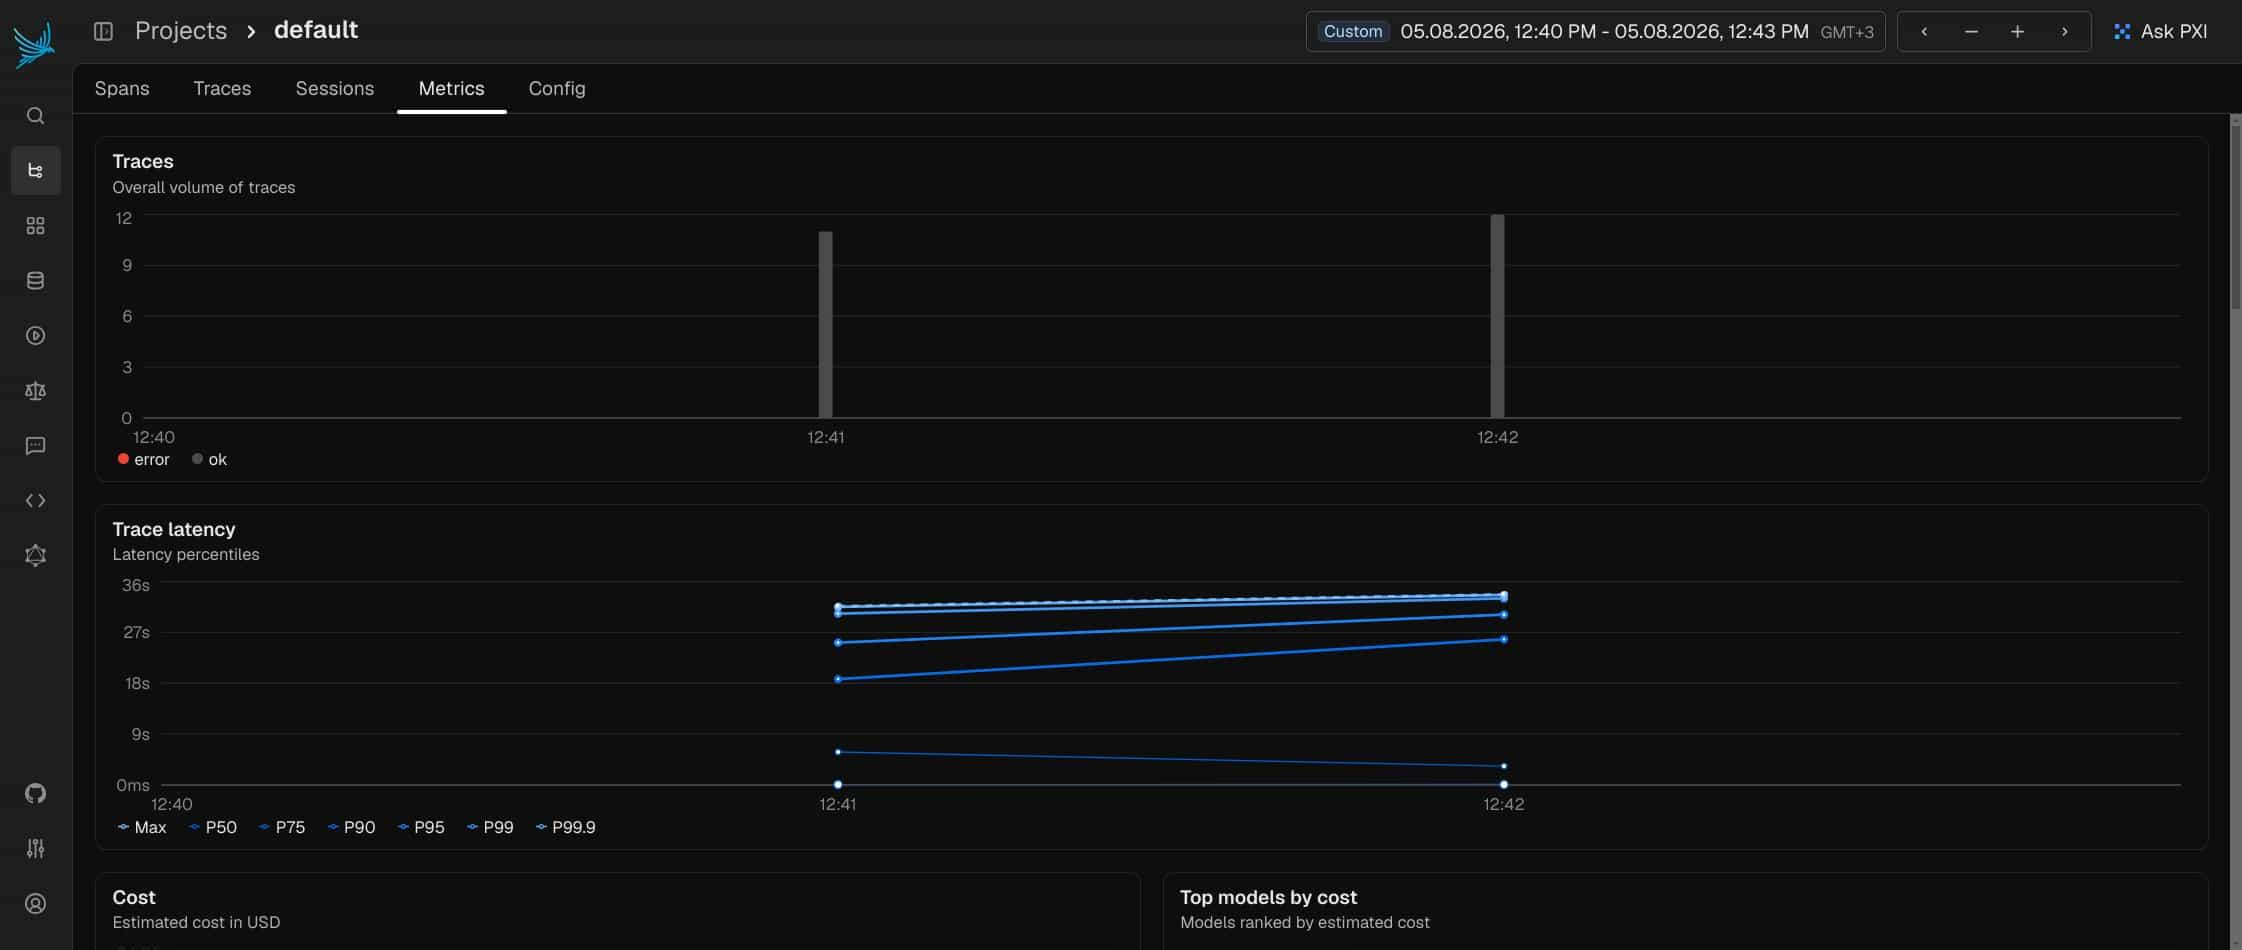

2. **Трасса RAG-запроса** - span-дерево для заземлённого ответа (например, вопрос про обеспечение заявки, где модель ссылается на ст. 44 и ст. 96). Наглядно видно все этапы: эмбеддинг, ретривал, реранкинг, генерация.


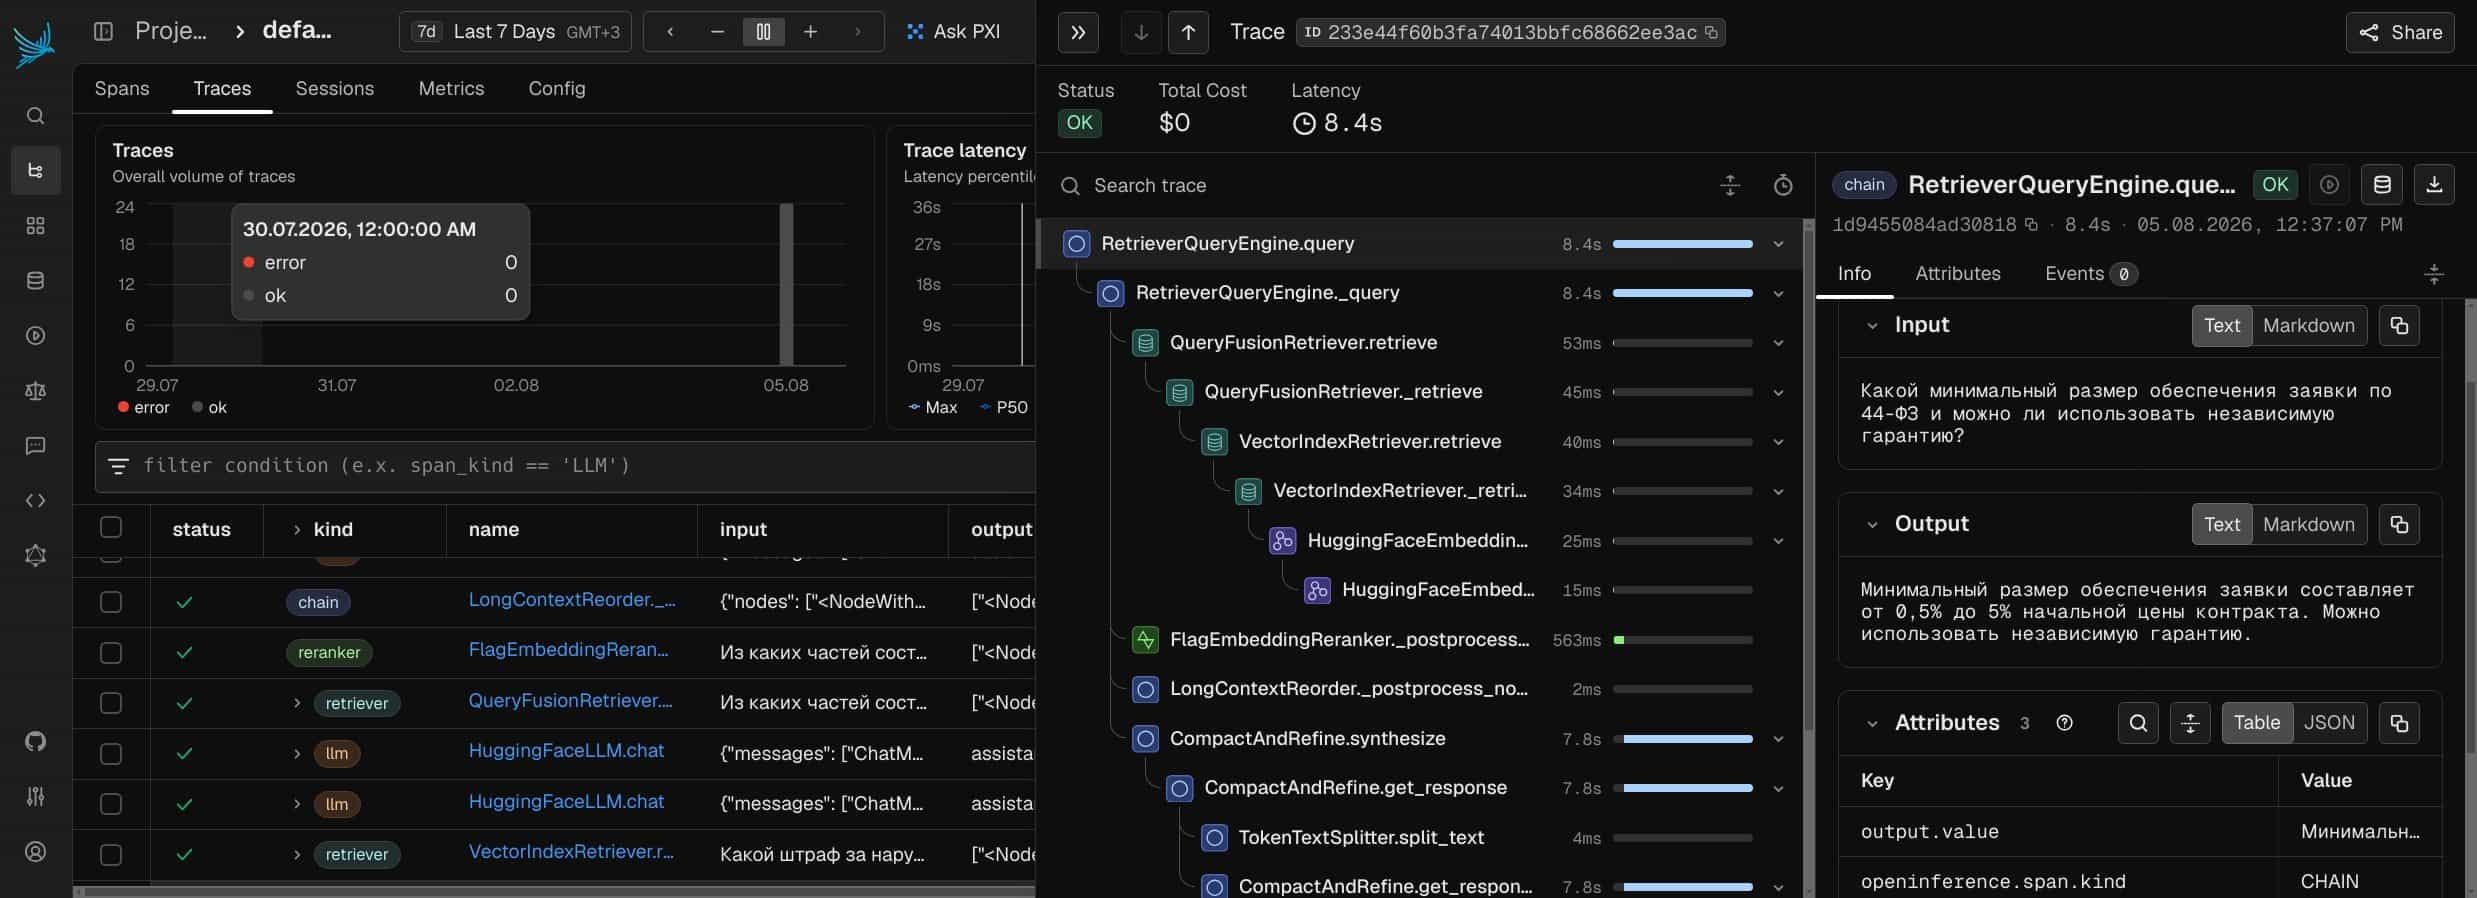